# Pitch Perturbation $\Delta\theta$

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import sympy
from sympy import Derivative, Matrix, Symbol, cos, sin

f = Symbol("f")
xc = Symbol("x_c")
yc = Symbol("y_c")

# Original camera pose
phi = Symbol("phi")  # Roll
theta = Symbol("theta")  # Pitch
psi = Symbol("psi")  # Yaw
x = Symbol("x")
y = Symbol("y")
# Non-zero otherwise degenerate homography since camera center aligned with plane
z = Symbol("z", nonzero=True)

# Viewpoint delta
dphi = Symbol("\Delta\phi")  # Roll
dtheta = Symbol("\Delta\\theta")  # Pitch
dpsi = Symbol("\Delta\psi")  # Yaw
dx = Symbol("\Delta x")
dy = Symbol("\Delta y")
dz = Symbol("\Delta z")

## Define homography matrix

In [2]:
H_inv = Matrix(
    [
        [1, xc / f * sin(dtheta), xc * (f * cos(dtheta) - f - yc * sin(dtheta)) / f],
        [0, cos(dtheta) + yc / f * sin(dtheta), -(f**2 + yc**2) / f * sin(dtheta)],
        [0, sin(dtheta) / f, cos(dtheta) - yc / f * sin(dtheta)],
    ]
)
H_inv

Matrix([
[1,                     x_c*sin(\Delta\theta)/f, x_c*(f*cos(\Delta\theta) - f - y_c*sin(\Delta\theta))/f],
[0, cos(\Delta\theta) + y_c*sin(\Delta\theta)/f,                    (-f**2 - y_c**2)*sin(\Delta\theta)/f],
[0,                         sin(\Delta\theta)/f,             cos(\Delta\theta) - y_c*sin(\Delta\theta)/f]])

## Apply projective transform

In [3]:
u = Symbol("u")
v = Symbol("v")

p0 = H_inv @ Matrix([u, v, 1])
p0 = p0 / p0[2]  # Normalize for non-homogeneous coordinates
p0 = sympy.simplify(p0)

u0 = p0[0]
v0 = p0[1]

In [4]:
u0

(f*u + v*x_c*sin(\Delta\theta) - x_c*(-f*cos(\Delta\theta) + f + y_c*sin(\Delta\theta)))/(f*cos(\Delta\theta) + v*sin(\Delta\theta) - y_c*sin(\Delta\theta))

In [5]:
u0.expand()

f*u/(f*cos(\Delta\theta) + v*sin(\Delta\theta) - y_c*sin(\Delta\theta)) + f*x_c*cos(\Delta\theta)/(f*cos(\Delta\theta) + v*sin(\Delta\theta) - y_c*sin(\Delta\theta)) - f*x_c/(f*cos(\Delta\theta) + v*sin(\Delta\theta) - y_c*sin(\Delta\theta)) + v*x_c*sin(\Delta\theta)/(f*cos(\Delta\theta) + v*sin(\Delta\theta) - y_c*sin(\Delta\theta)) - x_c*y_c*sin(\Delta\theta)/(f*cos(\Delta\theta) + v*sin(\Delta\theta) - y_c*sin(\Delta\theta))

In [6]:
u0_bis = xc + f * (u - xc) / (f * cos(dtheta) + v * sin(dtheta) - yc * sin(dtheta))
u0_bis

f*(u - x_c)/(f*cos(\Delta\theta) + v*sin(\Delta\theta) - y_c*sin(\Delta\theta)) + x_c

In [7]:
(u0 - u0_bis).expand().simplify()

0

In [8]:
v0

(v*(f*cos(\Delta\theta) + y_c*sin(\Delta\theta)) - (f**2 + y_c**2)*sin(\Delta\theta))/(f*cos(\Delta\theta) + v*sin(\Delta\theta) - y_c*sin(\Delta\theta))

In [9]:
v0.expand()

-f**2*sin(\Delta\theta)/(f*cos(\Delta\theta) + v*sin(\Delta\theta) - y_c*sin(\Delta\theta)) + f*v*cos(\Delta\theta)/(f*cos(\Delta\theta) + v*sin(\Delta\theta) - y_c*sin(\Delta\theta)) + v*y_c*sin(\Delta\theta)/(f*cos(\Delta\theta) + v*sin(\Delta\theta) - y_c*sin(\Delta\theta)) - y_c**2*sin(\Delta\theta)/(f*cos(\Delta\theta) + v*sin(\Delta\theta) - y_c*sin(\Delta\theta))

In [10]:
yc - f * (f * sin(dtheta) - (v - yc) * cos(dtheta)) / (
    f * cos(dtheta) + v * sin(dtheta) - yc * sin(dtheta)
)

-f*(f*sin(\Delta\theta) - (v - y_c)*cos(\Delta\theta))/(f*cos(\Delta\theta) + v*sin(\Delta\theta) - y_c*sin(\Delta\theta)) + y_c

## Compute gradient

In [11]:
du0_dK = Derivative(u0, dtheta, evaluate=True).simplify()
du0_dK

f*(f*u*sin(\Delta\theta) - f*x_c*sin(\Delta\theta) - u*v*cos(\Delta\theta) + u*y_c*cos(\Delta\theta) + v*x_c*cos(\Delta\theta) - x_c*y_c*cos(\Delta\theta))/(f*cos(\Delta\theta) + v*sin(\Delta\theta) - y_c*sin(\Delta\theta))**2

In [12]:
du0_dK.factor()

-f*(u - x_c)*(-f*sin(\Delta\theta) + v*cos(\Delta\theta) - y_c*cos(\Delta\theta))/(f*cos(\Delta\theta) + v*sin(\Delta\theta) - y_c*sin(\Delta\theta))**2

In [13]:
dv0_dK = Derivative(v0, dtheta, evaluate=True).simplify()
dv0_dK

f*(-f**2 - v**2 + 2*v*y_c - y_c**2)/(f*cos(\Delta\theta) + v*sin(\Delta\theta) - y_c*sin(\Delta\theta))**2

## Compute gradient derivative

In [14]:
Derivative(du0_dK, dtheta, evaluate=True).simplify()

f*(u - x_c)*(2*(-f*sin(\Delta\theta) + v*cos(\Delta\theta) - y_c*cos(\Delta\theta))**2 + (f*cos(\Delta\theta) + v*sin(\Delta\theta) - y_c*sin(\Delta\theta))**2)/(f*cos(\Delta\theta) + v*sin(\Delta\theta) - y_c*sin(\Delta\theta))**3

In [15]:
Derivative(dv0_dK, dtheta, evaluate=True).simplify()

-2*f*(f*sin(\Delta\theta) - v*cos(\Delta\theta) + y_c*cos(\Delta\theta))*(f**2 + v**2 - 2*v*y_c + y_c**2)/(f*cos(\Delta\theta) + v*sin(\Delta\theta) - y_c*sin(\Delta\theta))**3

## Plots

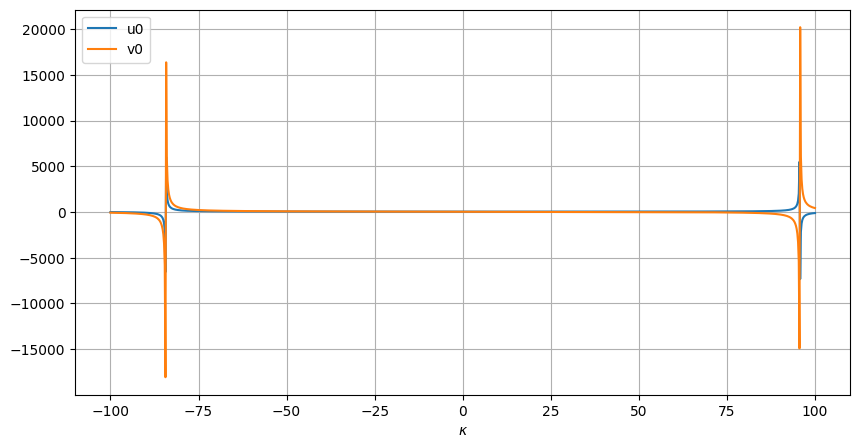

In [16]:
k_values = np.deg2rad(np.linspace(-100, 100, 1000))

u0_subs = u0.subs({f: 30, xc: 32, yc: 32, u: 43, v: 35})
v0_subs = v0.subs({f: 30, xc: 32, yc: 32, u: 43, v: 35})

u0_values = [u0_subs.subs({dtheta: val}).evalf() for val in k_values]
v0_values = [v0_subs.subs({dtheta: val}).evalf() for val in k_values]

u0_values = np.array(u0_values, dtype=float)
v0_values = np.array(v0_values, dtype=float)

plt.figure(figsize=(10, 5))
plt.plot(np.rad2deg(k_values), u0_values, label="u0")
plt.plot(np.rad2deg(k_values), v0_values, label="v0")
plt.xlabel(r"$\kappa$")
plt.legend()
plt.grid(True)
plt.show()